# Session 11 - SVM and Hyperparameter Tuning up (Gridsearch and randomizeSearch)

SVM model :

What is SVM?

Finds the best line (hyperplane) that separates classes with maximum margin.

Key Concepts
Hyperplane: A decision boundary separating different classes in feature space and is represented by the equation wx + b = 0 in linear classification.

Support Vectors: The closest data points to the hyperplane, crucial for determining the hyperplane and margin in SVM.

Margin: The distance between the hyperplane and the support vectors. SVM aims to maximize this margin for better classification performance.

Kernel: A function that maps data to a higher-dimensional space enabling SVM to handle non-linearly separable data.

Hard Margin: A maximum-margin hyperplane that perfectly separates the data without misclassifications.

Soft Margin: Allows some misclassifications by introducing slack variables, balancing margin maximization and misclassification penalties when data is not perfectly separable.

C: A regularization term balancing margin maximization and misclassification penalties. A higher C value forces stricter penalty for misclassifications.



Types of SVM: 

 1-SVC (Classification)  2- SVR (for regression)  3-NuSVS (the percent of poitns as support vector)

nu = what FRACTION of data can be errors - less --> hard punishment 

NuSVC(nu=0.1)   # At most 10% of data can be margin errors

NuSVC(nu=0.5)   # At most 50% can be errors

NuSVC(nu=0.01)  # At most 1% can be errors (hard margin)

What if data is not linearly separable?

When data is not linearly separable i.e it can't be divided by a straight line, SVM uses a technique called kernels to map the data into a higher-dimensional space where it becomes separable.

Linear Kernel: For linear separability.

Polynomial Kernel: Maps data into a polynomial space.

Radial Basis Function (RBF) Kernel: Transforms data into a space based on distances between data points.

Advantages

High-Dimensional Performance: SVM excels in high-dimensional spaces, making it suitable for image classification and gene expression analysis.

Nonlinear Capability: Utilizing kernel functions like RBF and polynomial SVM effectively handles nonlinear relationships.

Outlier Resilience: SVM can handle outliers by allowing some misclassifications using a soft margin.

Binary and Multiclass Support: SVM is effective for both binary classification and multiclass classification suitable for applications in text classification.

Memory Efficiency: It focuses on support vectors making it memory efficient compared to other algorithms.

Limitations

Slow Training: SVM can be slow for large datasets, affecting performance in SVM in data mining tasks.

Parameter Tuning Difficulty: Selecting the right kernel and adjusting parameters like C requires careful tuning, impacting SVM algorithms.

Noise Sensitivity: SVM struggles with noisy datasets and overlapping classes, limiting effectiveness in real-world scenarios.

Limited Interpretability: The complexity of the hyperplane in higher dimensions makes SVM less interpretable than other models.

Feature Scaling Sensitivity: Proper feature scaling is essential, otherwise SVM models may perform poorly.

C vs gamma

C	Margin width & error tolerance	"How much do I punish mistakes?"

Gamma	Influence of each data point	"How far does one point's influence reach?"

High C + High Gamma = Very complex → Overfitting ❌
  "Classify every point perfectly" + "Each point has tiny influence"
  → Model draws wiggly boundary around every point

Low C + Low Gamma = Very simple → Underfitting ❌
  "Allow many mistakes" + "Each point has wide influence"
  → Model draws almost straight line

High C + Low Gamma = Good for some problems ✅
  "Classify well" + "Smooth boundary"

Low C + High Gamma = Usually bad ❌
  "Allow mistakes" + "Wiggly boundary" → Contradicts itself


-------------------------------------

Hyperparameter Tuning up :

Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.

1- Grid Search 

1. GridSearchCV 
GridSearchCV is a brute-force technique for hyperparameter tuning. It trains the model using all possible combinations of specified hyperparameter values to find the best-performing setup. It is slow and uses a lot of computer power which makes it hard to use with big datasets or many settings. It works using below steps:

Create a grid of potential values for each hyperparameter.

Train the model for every combination in the grid.

Evaluate each model using cross-validation.

Select the combination that gives the highest score.


2- RandomizedSearchCV

2. RandomizedSearchCV 
As the name suggests RandomizedSearchCV picks random combinations of hyperparameters from the given ranges instead of checking every single combination like GridSearchCV.

In each iteration it tries a new random combination of hyperparameter values.

It records the model’s performance for each combination.

After several attempts it selects the best-performing set.









## SVC

In [22]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X,y = make_moons(n_samples=100, noise=0.8, random_state=42)

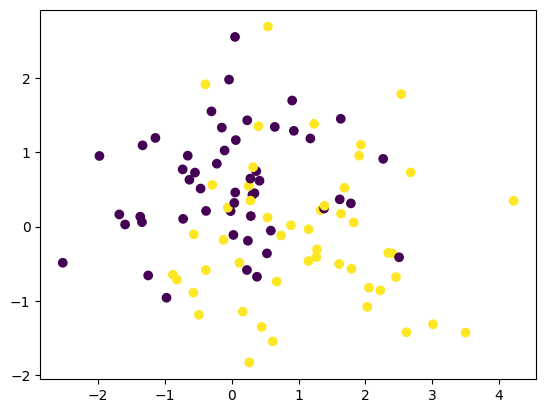

In [3]:
plt.scatter(X[:,0],X[:,1], c=y)

In [11]:
model = SVC(kernel = 'linear')
model.fit(X,y)
y_pred = model.predict(X)

#or
model = LinearSVC()
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75        50
           1       0.76      0.74      0.75        50

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100



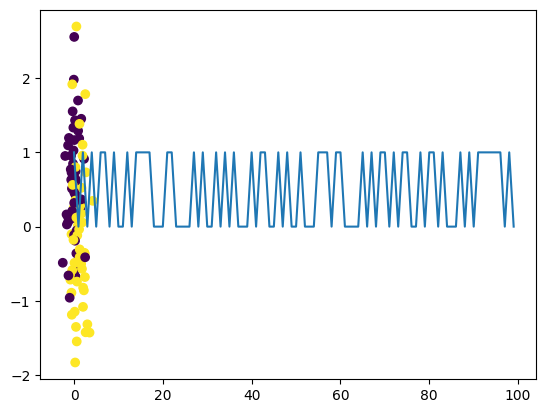

In [5]:
plt.scatter(X[:,0],X[:,1], c=y)
plt.plot(y_pred)

In [10]:
model2 = SVC (kernel = 'rbf')
model2.fit(X,y)
y_pred  = model2.predict(X)
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77        50
           1       0.78      0.76      0.77        50

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [18]:
model3 = LogisticRegression()
model3.fit(X,y)
y_pred = model3.predict(X)
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77        50
           1       0.78      0.72      0.75        50

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100



<Axes: >

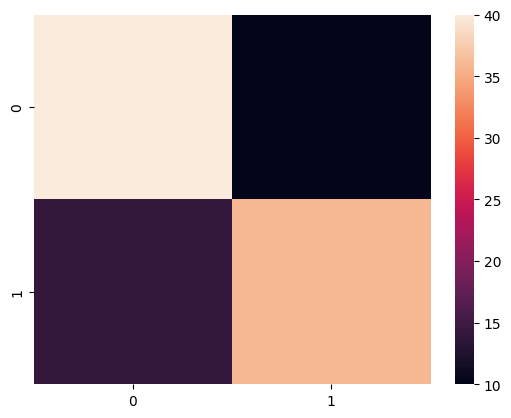

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm)

In [26]:
import numpy as np
from sklearn.datasets import load_digits, fetch_olivetti_faces
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import matplotlib.pyplot as plt

In [27]:
X, y = load_digits(return_X_y=True, as_frame=False)
np.unique(X) # so 0-16 must be scaled 

X = X/16

In [28]:
np.unique(y,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180], dtype=int64))

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, stratify=y)

In [30]:
#logistic 
model_1 = LogisticRegression()
model_1.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
# SVC
model_2 = SVC()
model_2.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
y_pred_1 = model_1.predict(X_test)
print(classification_report(y_test,y_pred_1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        37
           2       0.97      1.00      0.99        35
           3       1.00      0.95      0.97        37
           4       1.00      0.94      0.97        36
           5       1.00      0.97      0.99        36
           6       0.97      0.97      0.97        36
           7       1.00      1.00      1.00        36
           8       0.87      0.94      0.90        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.98       360
weighted avg       0.98      0.97      0.98       360



In [39]:
y_pred_2 = model_2.predict(X_test)

print(classification_report(y_test,y_pred_2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      0.97      0.99        36
           5       1.00      0.97      0.99        36
           6       0.97      1.00      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      1.00      0.99        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



<Axes: >

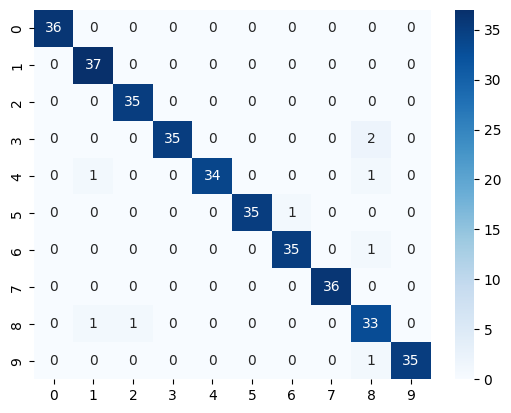

In [42]:
cm = confusion_matrix(y_test, y_pred_1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [43]:
# as you can see the SVC is better in calssification here 

## Hyperparameter Tuning up

from sklearn.model_selection import GridSearchCV

GridSearchCV(

    estimator,              # Model to tune
    param_grid,             # Dictionary of parameters to search
    scoring=None,           # Metric: 'accuracy','f1','precision','recall','roc_auc'
    n_jobs=-1,              # CPU cores (-1 = all)
    cv=5,                   # Cross-validation folds
    verbose=0,              # 0=silent, 1=progress, 2=details
    refit=True,             # Refit best model on full data?
    return_train_score=False, # Include training scores?
    error_score='raise',    # 'raise' or np.nan
    pre_dispatch='2*n_jobs' # Jobs dispatched during execution
)

In [18]:
clf = SVC()

param_dict = {
    'C':[0.1,4,50,100],
    'gamma'  : [.1,1,10,50,100],
    'kernel' :['poly','rbf','sigmoid']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_model = GridSearchCV(
    estimator = clf,
    param_grid = param_dict,
    cv = skf,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = True,
    return_train_score = True
)

grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 4, ...], 'gamma': [0.1, 1, ...], 'kernel': ['poly', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,4


In [19]:
grid_model.best_params_

{'C': 4, 'gamma': 0.1, 'kernel': 'rbf'}

In [20]:
grid_model.best_estimator_

,C,4
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
best_model = grid_model.best_estimator_

In [23]:
best_model.fit(X_train,y_train)

,C,4
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      0.92      0.96        36
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       1.00      0.97      0.99        35
           9       0.92      1.00      0.96        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [25]:
# All results as DataFrame
import pandas as pd
results = pd.DataFrame(grid_model.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.134297,0.066205,0.035703,0.016961,0.1,0.1,poly,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}",0.996528,0.979167,...,0.975627,0.014458,26,0.979983,0.983464,0.983478,0.984348,0.985217,0.983298,0.001780
1,0.310859,0.120084,0.170045,0.077314,0.1,0.1,rbf,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",0.972222,0.958333,...,0.952662,0.017742,27,0.949521,0.956484,0.953043,0.957391,0.960870,0.955462,0.003877
2,0.549058,0.237909,0.098426,0.042951,0.1,0.1,sigmoid,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'sigmoid'}",0.760417,0.784722,...,0.771746,0.027399,31,0.773716,0.774587,0.765217,0.791304,0.756522,0.772269,0.011554
3,0.076179,0.016099,0.023783,0.015307,0.1,1.0,poly,"{'C': 0.1, 'gamma': 1, 'kernel': 'poly'}",0.996528,0.975694,...,0.987476,0.007150,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,0.506993,0.083657,0.182495,0.046689,0.1,1.0,rbf,"{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}",0.468750,0.625000,...,0.487740,0.074017,32,0.530026,0.723238,0.578261,0.543478,0.599130,0.594827,0.068729
5,0.745909,0.039955,0.116951,0.045018,0.1,1.0,sigmoid,"{'C': 0.1, 'gamma': 1, 'kernel': 'sigmoid'}",0.104167,0.100694,...,0.114840,0.017591,37,0.103568,0.101828,0.114783,0.101739,0.139130,0.112210,0.014307
6,0.096857,0.022827,0.043061,0.043015,0.1,10.0,poly,"{'C': 0.1, 'gamma': 10, 'kernel': 'poly'}",0.996528,0.975694,...,0.987476,0.007150,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
7,0.778960,0.130645,0.223039,0.025655,0.1,10.0,rbf,"{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}",0.114583,0.100694,...,0.104380,0.005291,41,0.203655,0.101828,0.203478,0.101739,0.203478,0.162836,0.049849
8,0.529616,0.023553,0.084038,0.010784,0.1,10.0,sigmoid,"{'C': 0.1, 'gamma': 10, 'kernel': 'sigmoid'}",0.100694,0.100694,...,0.100905,0.000172,49,0.101828,0.101828,0.101739,0.101739,0.101739,0.101775,0.000043
9,0.140834,0.039174,0.011994,0.000373,0.1,50.0,poly,"{'C': 0.1, 'gamma': 50, 'kernel': 'poly'}",0.996528,0.975694,...,0.987476,0.007150,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


In [27]:
grid_model.best_score_ # Already the average of 5-fold CV! - cross validation

0.9923417537746806

In [97]:
# now see the cross validation
from sklearn.model_selection import cross_validate

reslut = cross_validate(
    best_model,
    X_train,y_train,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

reslut

{'fit_time': array([0.01793098, 0.05634809, 0.05727029, 0.05706692, 0.05823445]),
 'score_time': array([0.02716494, 0.03855872, 0.03832436, 0.03986287, 0.04030347]),
 'test_score': array([0.98611111, 0.98611111, 0.99651568, 0.99303136, 0.98954704]),
 'train_score': array([1.        , 0.99912968, 1.        , 1.        , 1.        ])}

## BTC for material I got 

In [28]:
import numpy as np
import yfinance as yf

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import pandas as pd

In [29]:
#df = yf.download("BTC-USD", start="2014-01-01", end="2025-12-31")
#df.to_csv("BTC.csv")
#df
df = pd.read_csv("BTC.csv")
df

,Date,Close,High,Low,Open,Volume
0,9/17/2014,457.334015,468.174011,452.421997,465.864014,2.105680e+07
1,9/18/2014,424.440002,456.859985,413.104004,456.859985,3.448320e+07
2,9/19/2014,394.795990,427.834992,384.532013,424.102997,3.791970e+07
3,9/20/2014,408.903992,423.295990,389.882996,394.673004,3.686360e+07
4,9/21/2014,398.821014,412.425995,393.181000,408.084992,2.658010e+07
...,...,...,...,...,...,...
4118,12/26/2025,87301.429690,89459.429690,86628.140630,87235.507810,4.245567e+10
4119,12/27/2025,87802.156250,87874.781250,87182.976560,87301.429690,1.374120e+10
4120,12/28/2025,87835.835940,87986.890630,87394.953130,87799.343750,1.515656e+10
4121,12/29/2025,87138.140630,90299.156250,86717.914060,87835.789060,4.841163e+10


In [30]:
df["Return"] = df["Close"] - df["Open"]
df["SMA_7"] =df["Close"].rolling(7).mean()
df["SMA_30"] =df["Close"].rolling(30).mean()

df['Direction'] = df["Return"].apply(lambda i: 1 if i > 0 else 0  )
df
df.dropna(inplace=True)


df['Date']=pd.to_datetime(df["Date"])
df['Year'] = df['Date'].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekDay"] = df["Date"].dt.weekday


In [33]:
df["Target"] = df["Direction"].shift(-1)
df.dropna(inplace=True)

df

,Date,Close,High,Low,Open,Volume,Return,SMA_7,SMA_30,Direction,Year,Month,Day,WeekDay,Target
29,2014-10-16,382.556000,398.807007,373.070007,394.518005,2.699000e+07,-11.962006,381.574720,384.112801,0,2014,10,16,3,1.0
30,2014-10-17,383.757996,385.477997,375.389008,382.756012,1.360070e+07,1.001984,384.745575,381.660267,1,2014,10,17,4,1.0
31,2014-10-18,391.441986,395.157989,378.971008,383.976013,1.141680e+07,7.465973,388.908857,380.560333,1,2014,10,18,5,0.0
32,2014-10-19,389.545990,393.938995,386.457001,391.253998,5.914570e+06,-1.708008,390.479854,380.385333,0,2014,10,19,6,0.0
33,2014-10-20,382.845001,390.084015,378.252014,389.230988,1.641900e+07,-6.385986,389.398568,379.516700,0,2014,10,20,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4116,2025-12-24,87611.960940,87956.882810,86411.796880,87404.320310,2.555030e+10,207.640630,87721.088170,89492.719532,1,2025,12,24,2,0.0
4117,2025-12-25,87234.742190,88501.789060,86949.257810,87608.320310,1.995322e+10,-373.578120,87974.264510,89489.147918,0,2025,12,25,3,1.0
4118,2025-12-26,87301.429690,89459.429690,86628.140630,87235.507810,4.245567e+10,65.921880,87859.699779,89381.916668,1,2025,12,26,4,1.0
4119,2025-12-27,87802.156250,87874.781250,87182.976560,87301.429690,1.374120e+10,500.726560,87782.293529,89265.809376,1,2025,12,27,5,1.0


In [34]:
X = df.drop(columns=["Date", "Target"]).values
y = df["Target"]
X.shape

(4092, 13)

In [51]:
#Fixed code
X = df[['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_7', 'SMA_30', 
        'Year', 'Month', 'Day', 'WeekDay']].values

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, shuffle=False)

In [53]:
clf = SVC(kernel="rbf")

param_dict = {
    "C":[0.001, 0.01, 0.1,0.5,1,5,10],
    "gamma":[0.001, 0.01, 0.1,0.5,1,5,10]
}

skf = StratifiedKFold(n_splits=5, shuffle=False)

grid_model = GridSearchCV(
    estimator=clf,
    param_grid=param_dict,
    cv=skf,
    scoring = "accuracy",
    n_jobs=-1,
    verbose=True,
    return_train_score=True,
)

grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 49 candidates, totalling 245 fits


,estimator,SVC()
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,0.001


In [54]:
grid_model.best_params_

{'C': 0.001, 'gamma': 0.001}

In [56]:
grid_model.best_score_

0.5288727035039802

In [57]:
best_model = grid_model.best_estimator_

In [59]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       394
         1.0       0.52      1.00      0.68       425

    accuracy                           0.52       819
   macro avg       0.26      0.50      0.34       819
weighted avg       0.27      0.52      0.35       819



C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [60]:
skf = StratifiedKFold(n_splits=5, shuffle=False)

model = LogisticRegression()
param_dict = {
    'max_iter':[100,1000,5000,10000,20000]
}

grid_model = GridSearchCV(
    estimator=model,
    param_grid=param_dict,
    cv=5,
    scoring = "accuracy",
    n_jobs=-1,
    verbose=True,
    return_train_score=True,
)

grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,LogisticRegression()
,param_grid,"{'max_iter': [100, 1000, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [61]:
grid_model.best_params_

{'max_iter': 100}

In [62]:
grid_model.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
grid_model.best_score_

0.4720101781170484

In [64]:
model = grid_model.best_estimator_

In [65]:
y_pred =model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.48      0.97      0.64       394
         1.0       0.52      0.03      0.05       425

    accuracy                           0.48       819
   macro avg       0.50      0.50      0.35       819
weighted avg       0.50      0.48      0.34       819



In [111]:
#Randomize
model = LogisticRegression()
param_dict = {
    'max_iter':[100,1000,5000,10000,20000]
}
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dict,
    n_iter=2,             # Tells the model to pick exactly 15 random combinations
    cv=skf,                # Correctly using your cross-validation split strategy
    scoring="accuracy",
    n_jobs=-1,             # Use all CPU cores
    random_state=42,       # Forces the random choices to be identical every run
    verbose=True,
    return_train_score=True
)

In [112]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,LogisticRegression()
,param_distributions,"{'max_iter': [100, 1000, ...]}"
,n_iter,2
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [113]:
model = grid_model.best_estimator_

In [114]:
y_pred =model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.49      0.55      0.52       393
         1.0       0.53      0.47      0.50       426

    accuracy                           0.51       819
   macro avg       0.51      0.51      0.51       819
weighted avg       0.51      0.51      0.51       819



## Fixed and Improved Code

Problems of your model :

The Three Structural Flaws Causing the Collapse

Culprit A: Missing Feature Scaling (The SVM Killer)Support Vector Machines (SVM) with an RBF kernel rely heavily on calculating Euclidean distances between data points to construct a decision boundary.  In your feature matrix $X$, you mixed absolute prices (Close $\approx \$60,000$), returns (Return $\approx \pm \$1,000$), and calendar cycles (WeekDay $\approx 0\text{ to }6$). When the SVM looks at these scales, a difference of $10,000$ in price completely obliteres a difference of $2$ in a weekday. The geometry of your feature space becomes massively warped along the price axes, forcing the decision boundary to flatten out and classify everything into a single uniform region.

Culprit B: Non-Stationary Data (The Logistic Regression Trap)Because you set shuffle=False (which is correct for time-series data to avoid data leakage), your data splits look like this:Training Set: Older historical data (e.g., 2014–2022) where Bitcoin prices were significantly lower.Test Set: Recent data (2023–2025) where Bitcoin prices are significantly higher.Absolute price metrics like Close, Open, SMA_7, and SMA_30 are non-stationary—their mean and variance change completely over time. When your Logistic Regression model encounters test values that are order of magnitudes larger than anything it saw during training, those massive numbers get multiplied by the trained weights. This pushes the inputs to the Sigmoid function to an extreme end ($\sigma(z) \rightarrow 0$ or $\sigma(z) \rightarrow 1$), locking the model into a single permanent prediction state for the entire test segment.

Culprit C: Absolute Values Have No Directional SignalKnowing that Bitcoin is trading at exactly $\$65,000$ today provides zero mathematical intuition about whether tomorrow will close higher or lower. The absolute price doesn't dictate tomorrow's velocity; the relative relationship of recent price changes does.





In [66]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [68]:
df = pd.read_csv("BTC.csv")
df

,Date,Close,High,Low,Open,Volume
0,9/17/2014,457.334015,468.174011,452.421997,465.864014,2.105680e+07
1,9/18/2014,424.440002,456.859985,413.104004,456.859985,3.448320e+07
2,9/19/2014,394.795990,427.834992,384.532013,424.102997,3.791970e+07
3,9/20/2014,408.903992,423.295990,389.882996,394.673004,3.686360e+07
4,9/21/2014,398.821014,412.425995,393.181000,408.084992,2.658010e+07
...,...,...,...,...,...,...
4118,12/26/2025,87301.429690,89459.429690,86628.140630,87235.507810,4.245567e+10
4119,12/27/2025,87802.156250,87874.781250,87182.976560,87301.429690,1.374120e+10
4120,12/28/2025,87835.835940,87986.890630,87394.953130,87799.343750,1.515656e+10
4121,12/29/2025,87138.140630,90299.156250,86717.914060,87835.789060,4.841163e+10


In [72]:
# make your data stationary 
df["Daily_Return_Pct"] = (df["Close"] - df["Open"]) / df["Open"]
df["SMA_7_Ratio"] = df["Close"] / df["Close"].rolling(7).mean()
df["SMA_30_Ratio"] = df["Close"] / df["Close"].rolling(30).mean()
df.dropna()

,Date,Close,High,Low,Open,Volume,Daily_Return_Pct,SMA_7_Ratio,SMA_30_Ratio,Direction
29,10/16/2014,382.556000,398.807007,373.070007,394.518005,2.699000e+07,-0.030321,1.002572,0.995947,0
30,10/17/2014,383.757996,385.477997,375.389008,382.756012,1.360070e+07,0.002618,0.997433,1.005496,1
31,10/18/2014,391.441986,395.157989,378.971008,383.976013,1.141680e+07,0.019444,1.006513,1.028594,1
32,10/19/2014,389.545990,393.938995,386.457001,391.253998,5.914570e+06,-0.004365,0.997608,1.024083,0
33,10/20/2014,382.845001,390.084015,378.252014,389.230988,1.641900e+07,-0.016407,0.983170,1.008770,0
...,...,...,...,...,...,...,...,...,...,...
4118,12/26/2025,87301.429690,89459.429690,86628.140630,87235.507810,4.245567e+10,0.000756,0.993646,0.976724,1
4119,12/27/2025,87802.156250,87874.781250,87182.976560,87301.429690,1.374120e+10,0.005736,1.000226,0.983603,1
4120,12/28/2025,87835.835940,87986.890630,87394.953130,87799.343750,1.515656e+10,0.000416,1.001891,0.985115,1
4121,12/29/2025,87138.140630,90299.156250,86717.914060,87835.789060,4.841163e+10,-0.007943,0.996127,0.978649,0


In [73]:
df['Direction'] = df["Daily_Return_Pct"].apply(lambda i: 1 if i > 0 else 0)

In [76]:
df["Target"] = df["Direction"].shift(-1)
df.dropna(inplace=True)
df

,Date,Close,High,Low,Open,Volume,Daily_Return_Pct,SMA_7_Ratio,SMA_30_Ratio,Direction,Target
29,10/16/2014,382.556000,398.807007,373.070007,394.518005,2.699000e+07,-0.030321,1.002572,0.995947,0,1.0
30,10/17/2014,383.757996,385.477997,375.389008,382.756012,1.360070e+07,0.002618,0.997433,1.005496,1,1.0
31,10/18/2014,391.441986,395.157989,378.971008,383.976013,1.141680e+07,0.019444,1.006513,1.028594,1,0.0
32,10/19/2014,389.545990,393.938995,386.457001,391.253998,5.914570e+06,-0.004365,0.997608,1.024083,0,0.0
33,10/20/2014,382.845001,390.084015,378.252014,389.230988,1.641900e+07,-0.016407,0.983170,1.008770,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
4116,12/24/2025,87611.960940,87956.882810,86411.796880,87404.320310,2.555030e+10,0.002376,0.998756,0.978984,1,0.0
4117,12/25/2025,87234.742190,88501.789060,86949.257810,87608.320310,1.995322e+10,-0.004264,0.991594,0.974808,0,1.0
4118,12/26/2025,87301.429690,89459.429690,86628.140630,87235.507810,4.245567e+10,0.000756,0.993646,0.976724,1,1.0
4119,12/27/2025,87802.156250,87874.781250,87182.976560,87301.429690,1.374120e+10,0.005736,1.000226,0.983603,1,1.0


In [80]:
X = df[["Daily_Return_Pct", "SMA_7_Ratio", "SMA_30_Ratio","Direction"]]
X

,Daily_Return_Pct,SMA_7_Ratio,SMA_30_Ratio,Direction
29,-0.030321,1.002572,0.995947,0
30,0.002618,0.997433,1.005496,1
31,0.019444,1.006513,1.028594,1
32,-0.004365,0.997608,1.024083,0
33,-0.016407,0.983170,1.008770,0
...,...,...,...,...
4116,0.002376,0.998756,0.978984,1
4117,-0.004264,0.991594,0.974808,0
4118,0.000756,0.993646,0.976724,1
4119,0.005736,1.000226,0.983603,1


In [82]:
y = df["Target"]
y

29      1.0
30      1.0
31      0.0
32      0.0
33      1.0
       ... 
4116    0.0
4117    1.0
4118    1.0
4119    1.0
4120    0.0
Name: Target, Length: 4092, dtype: float64

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [84]:
# 5. FEATURE SCALING (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
#OR
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced'))
])

In [87]:
param_dict = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1, 1]
}

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=False)

In [89]:
grid_model = GridSearchCV(
    estimator=pipeline,     # Pass the pipeline here instead of the raw model
    param_grid=param_dict,  # Uses the step__parameter syntax
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=True
)
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [91]:
grid_model.best_params_

{'svm__C': 1, 'svm__gamma': 0.1}

In [92]:
best_pipeline = grid_model.best_estimator_

In [93]:
y_pred = best_pipeline.predict(X_test)

In [95]:
grid_model.best_score_

0.5371216471741719

In [96]:
print(f"Best Parameters Found: {grid_model.best_params_}\n")
print(classification_report(y_test, y_pred))

Best Parameters Found: {'svm__C': 1, 'svm__gamma': 0.1}

              precision    recall  f1-score   support

         0.0       0.51      0.49      0.50       394
         1.0       0.54      0.56      0.55       425

    accuracy                           0.53       819
   macro avg       0.53      0.53      0.53       819
weighted avg       0.53      0.53      0.53       819



In [97]:
skf = StratifiedKFold(n_splits=5, shuffle=False)

model = LogisticRegression()
param_dict = {
    'max_iter':[100,1000,5000,10000,20000]
}

grid_model = GridSearchCV(
    estimator=model,
    param_grid=param_dict,
    cv=5,
    scoring = "accuracy",
    n_jobs=-1,
    verbose=True,
    return_train_score=True,
)

grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,LogisticRegression()
,param_grid,"{'max_iter': [100, 1000, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [98]:
best_pipeline = grid_model.best_estimator_

In [99]:
y_pred = best_pipeline.predict(X_test)

In [100]:
print(f"Best Parameters Found: {grid_model.best_params_}\n")
print(classification_report(y_test, y_pred))

Best Parameters Found: {'max_iter': 100}

              precision    recall  f1-score   support

         0.0       0.52      0.25      0.34       394
         1.0       0.53      0.79      0.63       425

    accuracy                           0.53       819
   macro avg       0.53      0.52      0.49       819
weighted avg       0.53      0.53      0.49       819



Best Parameters: {'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__n_estimators': 200}

              precision    recall  f1-score   support

         0.0       0.49      0.55      0.52       393
         1.0       0.53      0.47      0.50       426

    accuracy                           0.51       819
   macro avg       0.51      0.51      0.51       819
weighted avg       0.51      0.51      0.51       819

